## Librerias

In [1]:
#!pip install -q gluonts torch lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 31.3 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from gluonts.dataset.common import ListDataset
from gluonts.dataset.field_names import FieldName

# Construcción del dataset DeepAR con GluonTS



En este notebook construiremos el dataset compatible con DeepAR.

Usaremos:

- Matriz de ventas por serie.
- Covariables temporales globales.
- Covariables estáticas codificadas.

DeepAR aprende un modelo global usando muchas series relacionadas y genera pronósticos probabilísticos autoregresivos.

Datos

In [8]:
PATH = "/content/"

train_target_matrix = np.load(PATH + "train_target_matrix_CA.npy")
valid_target_matrix = np.load(PATH + "valid_target_matrix_CA.npy")

train_time_features_array = np.load(PATH + "train_time_features_array_CA.npy")
valid_time_features_array = np.load(PATH + "valid_time_features_array_CA.npy")

static_cat_encoded = pd.read_parquet(PATH + "static_cat_encoded_CA.parquet")
series_metadata = pd.read_parquet(PATH + "series_metadata_CA.parquet")
calendar_hist = pd.read_parquet(PATH + "calendar_hist_CA.parquet")

with open(PATH + "deepar_dataset_config_CA.pkl", "rb") as f:
    config = pickle.load(f)

print("train_target_matrix:", train_target_matrix.shape)
print("valid_target_matrix:", valid_target_matrix.shape)
print("train_time_features_array:", train_time_features_array.shape)
print("valid_time_features_array:", valid_time_features_array.shape)
print("static_cat_encoded:", static_cat_encoded.shape)
print(config)

train_target_matrix: (12196, 1885)
valid_target_matrix: (12196, 1913)
train_time_features_array: (5, 1885)
valid_time_features_array: (5, 1913)
static_cat_encoded: (12196, 5)
{'freq': 'D', 'prediction_length': 28, 'context_length': 56, 'start_date': Timestamp('2011-01-29 00:00:00'), 'static_cardinalities': {'item_id': 3049, 'dept_id': 7, 'cat_id': 3, 'store_id': 4, 'state_id': 1}, 'num_dynamic_features': 5}


In [9]:
freq = config["freq"]
prediction_length = config["prediction_length"]
context_length = config["context_length"]
start_date = config["start_date"]
static_cardinalities = list(config["static_cardinalities"].values())

print("freq:", freq)
print("prediction_length:", prediction_length)
print("context_length:", context_length)
print("start_date:", start_date)
print("static_cardinalities:", static_cardinalities)
print("num_dynamic_features:", train_time_features_array.shape[0])

freq: D
prediction_length: 28
context_length: 56
start_date: 2011-01-29 00:00:00
static_cardinalities: [3049, 7, 3, 4, 1]
num_dynamic_features: 5


Funcion para contruir el dataset

In [10]:
def build_gluonts_dataset(
    target_matrix,
    time_features_array,
    static_cat_encoded,
    start_date,
    freq="D"
):
    data = []

    for i in range(target_matrix.shape[0]):
        data.append({
            FieldName.START: start_date,
            FieldName.TARGET: target_matrix[i].astype("float32"),
            FieldName.FEAT_DYNAMIC_REAL: time_features_array.astype("float32"),
            FieldName.FEAT_STATIC_CAT: static_cat_encoded.iloc[i].values.astype("int64"),
        })

    return ListDataset(data, freq=freq)

Creamos el train y valid datatset

In [11]:
train_ds = build_gluonts_dataset(
    target_matrix=train_target_matrix,
    time_features_array=train_time_features_array,
    static_cat_encoded=static_cat_encoded,
    start_date=start_date,
    freq=freq
)

valid_ds = build_gluonts_dataset(
    target_matrix=valid_target_matrix,
    time_features_array=valid_time_features_array,
    static_cat_encoded=static_cat_encoded,
    start_date=start_date,
    freq=freq
)

print("train_ds y valid_ds creados correctamente.")

train_ds y valid_ds creados correctamente.


In [12]:
first_entry = next(iter(train_ds))

print(first_entry.keys())
print("target:", first_entry[FieldName.TARGET].shape)
print("feat_dynamic_real:", first_entry[FieldName.FEAT_DYNAMIC_REAL].shape)
print("feat_static_cat:", first_entry[FieldName.FEAT_STATIC_CAT])
print("start:", first_entry[FieldName.START])

dict_keys(['start', 'target', 'feat_dynamic_real', 'feat_static_cat'])
target: (1885,)
feat_dynamic_real: (5, 1885)
feat_static_cat: [0 0 0 0 0]
start: 2011-01-29


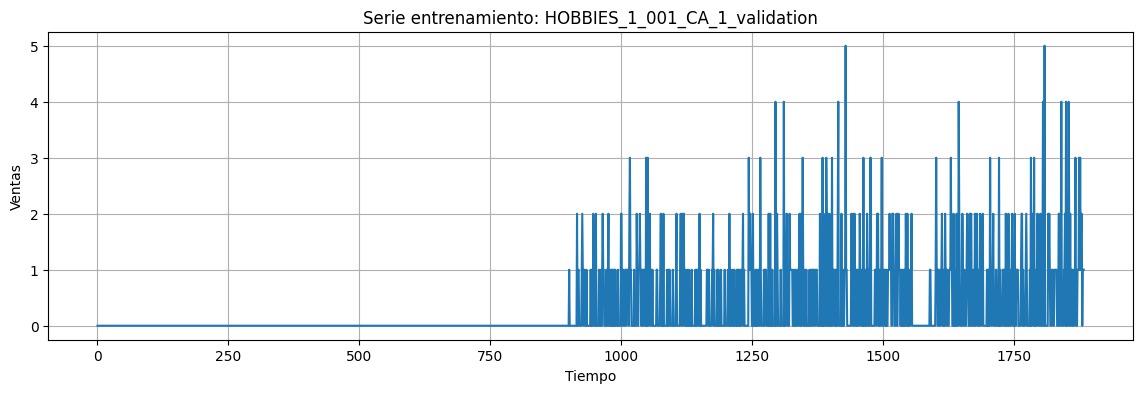

In [13]:
idx = 0

plt.figure(figsize=(14, 4))
plt.plot(train_target_matrix[idx])
plt.title(f"Serie entrenamiento: {series_metadata.iloc[idx]['id']}")
plt.xlabel("Tiempo")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

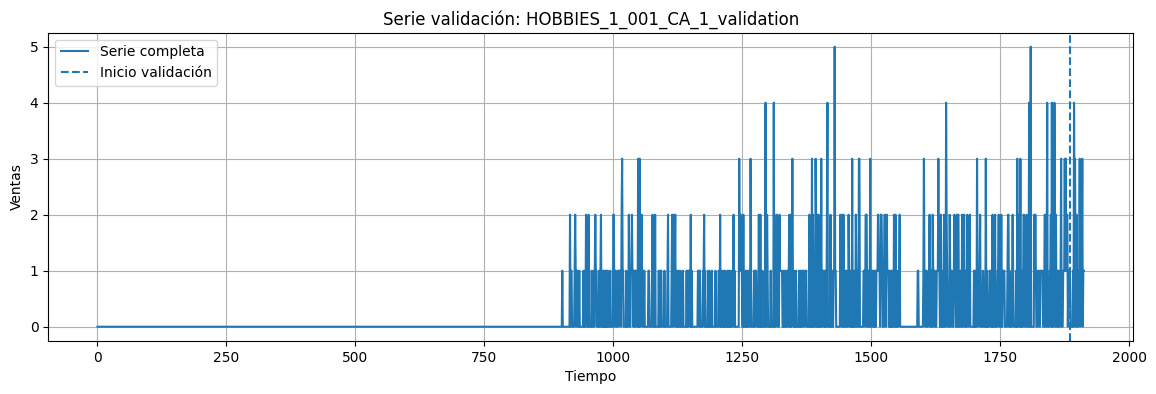

In [14]:
idx = 0

plt.figure(figsize=(14, 4))
plt.plot(valid_target_matrix[idx], label="Serie completa")
plt.axvline(
    valid_target_matrix.shape[1] - prediction_length,
    linestyle="--",
    label="Inicio validación"
)
plt.title(f"Serie validación: {series_metadata.iloc[idx]['id']}")
plt.xlabel("Tiempo")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
with open(PATH + "deepar_dataset_config_CA.pkl", "wb") as f:
    pickle.dump(
        {
            "freq": freq,
            "prediction_length": prediction_length,
            "context_length": context_length,
            "start_date": start_date,
            "static_cardinalities": config["static_cardinalities"],
            "num_dynamic_features": train_time_features_array.shape[0],
        },
        f
    )

print("Configuración final guardada.")

Configuración final guardada.


In [16]:
from google.colab import files

files.download("/content/deepar_dataset_config_CA.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

En este notebook se construyeron los datasets `train_ds` y `valid_ds` en formato GluonTS.

Cada entrada contiene:

- `target`: ventas históricas de una serie.
- `start`: fecha inicial de la serie.
- `feat_dynamic_real`: covariables temporales conocidas.
- `feat_static_cat`: variables categóricas estáticas.

Con esto ya podemos pasar al entrenamiento de DeepAR.